In [1]:
from transformers import pipeline
import torch
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np

from qwen_vl_utils import process_vision_info

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Qwen3VLForConditionalGeneration
)
import re
from PIL import Image
import json 
import os

os.environ['CUDA_VISIBLE_DEVICES'] = "5"

In [10]:
from huggingface_hub import snapshot_download

# local_dir = "./Qwen2.5-VL-RS"
# model_id = "AdaptLLM/remote-sensing-Qwen2.5-VL-3B-Instruct"
# snapshot_download(repo_id=model_id, local_dir=local_dir)
# model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
#     local_dir, torch_dtype="auto", device_map=5
# )

model_id = "Qwen/Qwen3-VL-8B-Instruct"
local_dir = "./Qwen3-VL-3B-Instruct"
snapshot_download(repo_id=model_id, local_dir=local_dir)
model = Qwen3VLForConditionalGeneration.from_pretrained(
    local_dir, torch_dtype="auto", device_map=5
)


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

In [11]:
next(model.parameters()).device

device(type='cuda', index=5)

In [12]:
processor = AutoProcessor.from_pretrained(local_dir)

(1169, 1215, 3)


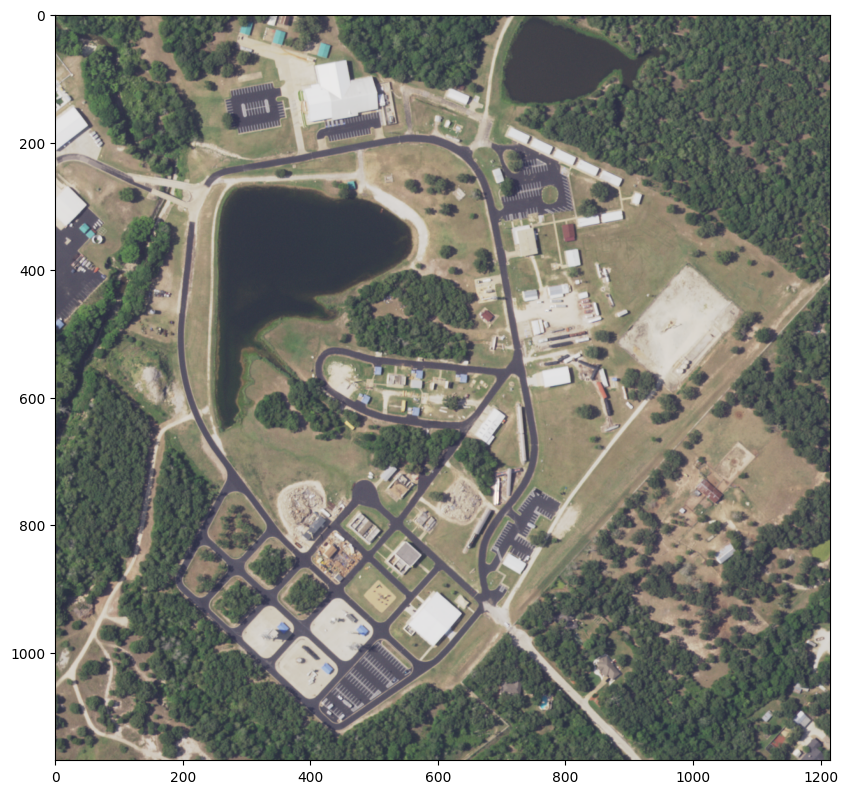

In [13]:
sample_img = xr.open_dataset('../data/disaster_city.nc')

rgb = sample_img.to_array()[1].values[:3, :, :]
rgb = np.moveaxis(rgb, 0, -1).astype('uint8')
print (rgb.shape)

plt.figure(figsize = (10, 10))
plt.imshow(rgb)

In [14]:
# {'polygon': [[x1, y1], [x2, y2], ...], 'label': 'object_name'}

In [20]:
image = Image.fromarray(rgb)
prompt_det = """
You are an expert in satellite image analysis.

Task:
Detect every individual object in the image. Each object must be separate. 
Do NOT merge multiple objects into one box.

Classes:
- building
- road
- water

Instructions:
1. Return each object instance as a separate dictionary.
2. Each dictionary must contain:
   - "label": the object class
   - "bbox": [x1, y1, x2, y2] (pixel coordinates)
3. Return only JSON, strictly formatted. No explanations.
4. Do not return more than 50 objects

Example output:

{
  "detections": [
    {"label": "building", "bbox": [400, 120, 520, 240]},
    {"label": "road", "bbox": [0, 500, 300, 560]},
    {"label": "road", "bbox": [310, 500, 600, 560]}
  ]
}

Return each object instance as a separate dictionary.
Do NOT put multiple "bbox" keys in the same dictionary.
Return only a list of dictionaries. RETURN A VALID JSON

THE following is invalid format for a JSON since keys should be unique
{
{
  "detections": [
    {"label": "tree", "bbox": [120, 340, 180, 400], "bbox":[120, 340, 180, 400] },
  ]
}
}
"""

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
            },
            {"type": "text", "text": prompt_det},
        ],
    }
]
# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda:5")

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=10000)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

print(output_text[0])

{
  "detections": [
    {"label": "building", "bbox": [320, 60, 420, 150]},
    {"label": "building", "bbox": [450, 770, 525, 850]},
    {"label": "building", "bbox": [425, 700, 475, 750]},
    {"label": "building", "bbox": [375, 665, 420, 710]},
    {"label": "building", "bbox": [330, 680, 370, 720]},
    {"label": "building", "bbox": [300, 620, 350, 670]},
    {"label": "building", "bbox": [430, 610, 465, 650]},
    {"label": "building", "bbox": [460, 660, 495, 700]},
    {"label": "building", "bbox": [540, 525, 585, 580]},
    {"label": "building", "bbox": [625, 470, 665, 500]},
    {"label": "building", "bbox": [635, 350, 665, 380]},
    {"label": "building", "bbox": [655, 315, 680, 340]},
    {"label": "building", "bbox": [650, 280, 675, 305]},
    {"label": "building", "bbox": [680, 200, 705, 230]},
    {"label": "building", "bbox": [600, 280, 625, 320]},
    {"label": "building", "bbox": [560, 200, 585, 230]},
    {"label": "building", "bbox": [500, 100, 535, 130]},
    {"label"

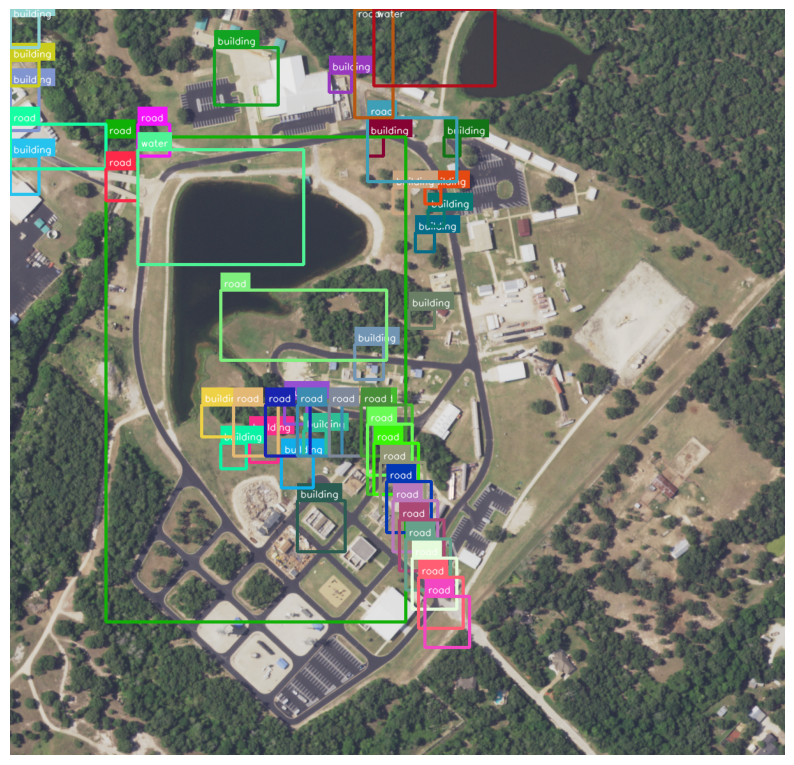

In [28]:
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

# clean model output
clean_output = output_text[0].strip().replace("```json","").replace("```","").strip()

# parse JSON as list
data = json.loads(clean_output)  # top-level is a list


# flatten all bboxes
flat_detections = []

for det in data['detections']:
    label = det["label"]
    # loop over all keys starting with 'bbox'
    for k, v in det.items():
        if k.startswith("bbox") and isinstance(v, list) and len(v) == 4:
            flat_detections.append({"label": label, "bbox": v})

# visualize
to_draw = rgb.copy()
height, width = to_draw.shape[:2]

colors = [tuple(np.random.randint(0,256,3).tolist()) for _ in flat_detections]
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
thickness = 1

for i, det in enumerate(flat_detections):
    label = det["label"]
    x1, y1, x2, y2 = det["bbox"]

    # draw bounding box
    cv2.rectangle(to_draw, (x1, y1), (x2, y2), colors[i], 3)

    # text size
    (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)
    

    # label box coords (clip to image)
    box_x1 = max(0, x1)
    box_y1 = max(0, y1 - th - baseline - 10)
    box_x2 = min(width, x1 + tw + 10)
    box_y2 = y1

    # draw filled rectangle behind text
    cv2.rectangle(to_draw, (box_x1, box_y1), (box_x2, box_y2), colors[i], -1)

    # draw text
    text_x = box_x1 + 5
    text_y = box_y2 - 5
    text_y = max(th, text_y)
    cv2.putText(to_draw, label, (text_x, text_y), font, font_scale, (255,255,255), thickness, cv2.LINE_AA)

plt.figure(figsize=(10,10))
plt.imshow(to_draw)
plt.axis("off")
plt.show()